<a href="https://colab.research.google.com/github/hueglijoshua/CVI03.HS24-Computer-Vision/blob/main/04a_YOLO_object_detection_model_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First clone the repository locally:

git clone git@github.com:facebookresearch/segment-anything.git

cd segment-anything; pip install -e .

In [2]:
!pip install opencv-python pycocotools matplotlib onnxruntime onnx
!pip install segment-anything
!pip install torch torchvision
!pip install sam2
!pip install ultralytics


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Automatic segmentation unsing segment-anything from meta

This notebooks aims to give a template to segment an individual dataset/pictures to further finetune a yolo model.

In [12]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
import os
import torch
import requests
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [20]:
# helper functions
def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2) 
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))    

def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        show_mask(mask, plt.gca(), borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, plt.gca())
        if box_coords is not None:
            # boxes
            show_box(box_coords, plt.gca())
        if len(scores) > 1:
            plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()
        

In [21]:
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

In [26]:
# checkpoint-URL 
url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"

# Define the path where you want to save the checkpoint
save_path = "./segment-anything/sam2_/sam_vit_h_4b8939.pth"

# Send a GET request to download the file
response = requests.get(url)

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Save the content to a file
    with open(save_path, 'wb') as f:
        f.write(response.content)
    print(f"Checkpoint downloaded successfully and saved to {save_path}")
else:
    print("Failed to download checkpoint")


Checkpoint downloaded successfully and saved to ./segment-anything/sam2/sam_vit_h_4b8939.pth


In [6]:
# Load SAM model
sam = sam_model_registry["default"](checkpoint="./segment-anything/sam2_/sam_vit_h_4b8939.pth")
sam.to(device="cuda" if torch.cuda.is_available() else "cpu")

# Load image for segmentation
image = Image.open("./segment-anything/sam2_/test_xray.jpg")
image = np.array(image.convert("RGB"))

# Initialize the predictor
predictor = SamPredictor(sam)
predictor.set_image(image)

# Predict segmentation masks
masks = predictor.predict()

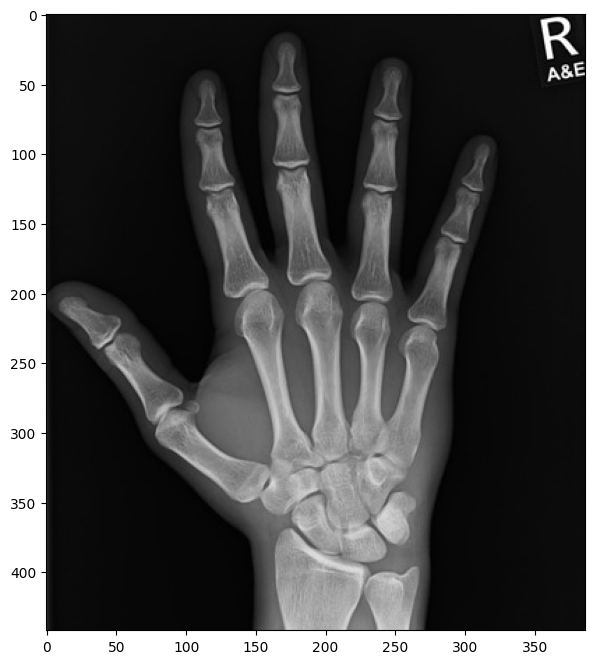

In [28]:
plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis('on')
plt.show()

# Automatically generating object masks with SAM

In [8]:
sam_checkpoint = "./segment-anything/sam2_/sam_vit_h_4b8939.pth"
model_type = "vit_h"
device = "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

mask_generator = SamAutomaticMaskGenerator(sam)


In [9]:
masks = mask_generator.generate(image)

In [34]:
print(len(masks))
print(masks[0].keys())

45
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


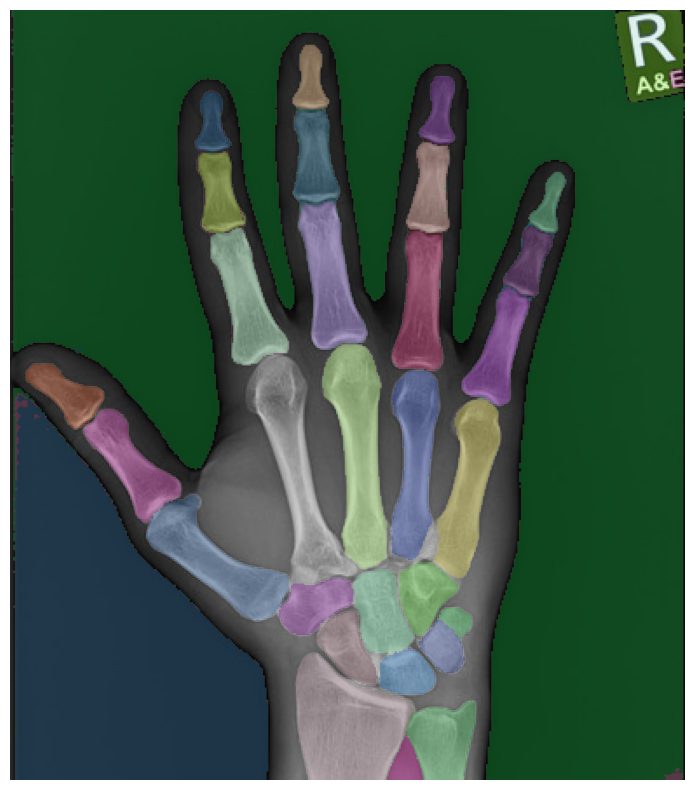

In [37]:
plt.figure(figsize=(10,10))
plt.imshow(image)
show_anns(masks)
plt.axis('off')
plt.show() 

There are several hyperparameters to finetune this automatic segmentation:

In [38]:
mask_generator_2 = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,                        # A higher value result in more detailed predictions
    pred_iou_thresh=0.86,                      # Predictions with an IoU lower than this threshold will be discarded
    stability_score_thresh=0.92,               # Masks with a stability score lower than this value are discarded
    crop_n_layers=1,                           # Defines # of layers in crop used for mask prediction. Helps generating more precise masks around object
    crop_n_points_downscale_factor=2,          # Downscales # of points for cropping. can speed up process while sacrificing precision
    min_mask_region_area=100,                  # minimum area for a mask region. Smaller regions will be discarded.
)

In [39]:
masks2 = mask_generator_2.generate(image)

In [40]:
len(masks2)

43

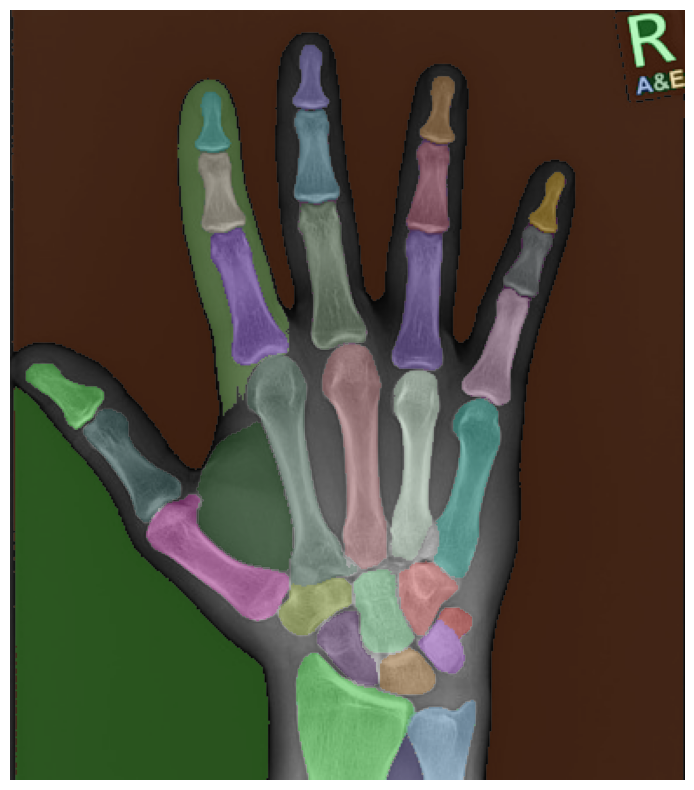

In [41]:
plt.figure(figsize=(10,10))
plt.imshow(image)
show_anns(masks2)
plt.axis('off')
plt.show() 

Since there are limitations with the customization of the segmentation, another approach is needed.